In [1]:
%load_ext autoreload
%autoreload 2

In [185]:
from sppaper.common.plot import setup_matplotlib_params

setup_matplotlib_params()

In [164]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import imageio.v3 as iio
import seaborn as sns
from pathlib import Path
from tqdm import tqdm, trange

from sppaper.kinematics.trajectory import inv_align_traj
from sppaper.kinematics.data import align_smooth_decompose_trajectories

In [229]:
VISUALIZED_SIM_DIR = Path("../../output_data/neuromechfly_replay/kp150_damp0.5_slidfric2.0/snippet21")
VIDEO_PLAYBACK_SPEED = 0.1
VIDEO_OUTPUT_FPS = 33
VISUALIZED_SIM_TIMERANGE = (0.5, 2.5)
OUTPUT_VIDEO_BLOCKDIM = 900

VIDEO_OUTPUT_DT = 1 / (VIDEO_OUTPUT_FPS / VIDEO_PLAYBACK_SPEED)

In [4]:
with open(VISUALIZED_SIM_DIR / "sim_data.pkl", "rb") as f:
    sim_data = pickle.load(f)

In [5]:
kinematic_snippet = sim_data["snippet"]
sim_results = sim_data["sim_results"]

In [6]:
traj_info = align_smooth_decompose_trajectories(kinematic_snippet, sim_results)
align_info = traj_info["rec_traj_alignment_transform"]

In [7]:
import numpy as np
import cv2
from scipy.signal import savgol_filter

def get_centerpos_and_heading(neck_pos, thorax_pos, filter_window=None):
    """
    Compute smoothed center position and heading of the fly.

    Args:
        neck_pos:      (L, 2) array of (x, y) pixel positions of the neck.
        thorax_pos:    (L, 2) array of (x, y) pixel positions of the thorax.
        filter_window: Odd integer window length for Savitzky-Golay filter,
                       or None to skip filtering.

    Returns:
        center_pos: (L, 2) smoothed thorax positions.
        heading:    (L,) unwrapped heading in radians.
    """
    diff = neck_pos - thorax_pos
    heading_raw = np.arctan2(diff[:, 1], diff[:, 0])
    heading = np.unwrap(heading_raw)

    if filter_window is not None and filter_window > 1:
        center_pos = np.stack([
            savgol_filter(thorax_pos[:, 0], filter_window, 2),
            savgol_filter(thorax_pos[:, 1], filter_window, 2),
        ], axis=1)
        heading = savgol_filter(heading, filter_window, 2)
    else:
        center_pos = thorax_pos.astype(float).copy()

    return center_pos, heading


def crop_single_image(full_image, center_pos, heading, bbox_sidelen=720, center_offset=(0, 0)):
    """
    Rotate the image so the fly faces up, then crop a square around the center.

    Args:
        full_image:    H x W or H x W x C numpy array.
        center_pos:    (x, y) pixel coordinate of the thorax.
        heading:       Scalar heading in radians.
        bbox_sidelen:  Side length of the square output patch in pixels.
        center_offset: (lateral, forward) offset in pixels in the fly's body frame.
                       forward (+) is toward the neck; lateral (+) is to the fly's right.
                       e.g. (0, 10) shifts the center 10 px toward the neck.

    Returns:
        cropped_image: (bbox_sidelen, bbox_sidelen[, C]) array, zero-padded if out of bounds.
    """
    # Apply center_offset in the fly's body frame
    lat_off, fwd_off = center_offset
    fwd = np.array([np.cos(heading), np.sin(heading)])
    rgt = np.array([np.sin(heading), -np.cos(heading)])
    cx, cy = center_pos + fwd_off * fwd + lat_off * rgt

    cx, cy = int(round(cx)), int(round(cy))
    h, w = full_image.shape[:2]

    angle_deg = -np.degrees(heading) - 90.0
    M = cv2.getRotationMatrix2D((cx, cy), angle_deg, scale=1.0)
    rotated = cv2.warpAffine(full_image, M, (w, h),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_CONSTANT,
                             borderValue=0)

    half = bbox_sidelen // 2
    x0, x1 = cx - half, cx + half
    y0, y1 = cy - half, cy + half

    pad_left  = max(0, -x0)
    pad_right = max(0, x1 - w)
    pad_top   = max(0, -y0)
    pad_bot   = max(0, y1 - h)

    x0c, x1c = x0 + pad_left, x1 - pad_right
    y0c, y1c = y0 + pad_top,  y1 - pad_bot

    crop = rotated[y0c:y1c, x0c:x1c]

    if any([pad_left, pad_right, pad_top, pad_bot]):
        pad_width = [(pad_top, pad_bot), (pad_left, pad_right)]
        if full_image.ndim == 3:
            pad_width.append((0, 0))
        crop = np.pad(crop, pad_width, mode='constant', constant_values=0)

    return crop

In [8]:
rec_centerpos, rec_heading = get_centerpos_and_heading(
    kinematic_snippet.neck_pos_px, kinematic_snippet.thorax_pos_px, filter_window=33
)

In [9]:
sim_bottomcam_frames = iio.imread(VISUALIZED_SIM_DIR / "bottom_cam.mp4")
sim_headings_smooth = savgol_filter(sim_results["heading_inputmatched"], 33, 2)

In [225]:
frame_pairs = []

for i_nmf_frame in range(sim_bottomcam_frames.shape[0]):
    sim_time_s = VIDEO_PLAYBACK_SPEED * i_nmf_frame / VIDEO_OUTPUT_FPS
    i_recsnippet_frame = int(np.round((sim_time_s) * kinematic_snippet.data_fps))
    i_fullrecording_frame = i_recsnippet_frame + kinematic_snippet.start_idx

    if VISUALIZED_SIM_TIMERANGE[0] <= sim_time_s <= VISUALIZED_SIM_TIMERANGE[1]:
        frame_pairs.append((i_nmf_frame, i_recsnippet_frame, i_fullrecording_frame))

frame_pairs_full = frame_pairs[:]

In [ ]:
spotlight_recording_path = (
    kinematic_snippet.exp_trial_dir / "processed/fullsize_behavior_video.mkv"
)
frames_to_read = {i for _, _, i in frame_pairs}
spotlight_frames = {}
with iio.imopen(spotlight_recording_path, "r", plugin="pyav") as spotlight_vid:
    for i, frame in enumerate(tqdm(spotlight_vid.iter())):
        if i > max(frames_to_read):
            break
        if i in frames_to_read:
            spotlight_frames[i] = frame

1675it [00:33, 50.15it/s]


In [240]:
import sppaper.kinematics.visualize as viz

In [241]:
sim_frame_center = (
    sim_bottomcam_frames.shape[1] // 2,
    sim_bottomcam_frames.shape[2] // 2,
)

# Recorded and simulated trajectory plotters
traj_indices = [
    i_recsnippet_frame
    for i_nmf_frame, i_recsnippet_frame, i_fullrecording_frame in frame_pairs
]
rectraj_plotter = viz.TrajectoryVideoPlotter(
    xypos_ts=traj_info["basetraj_rec_filtered"][traj_indices],
    heading_ts=traj_info["baseheading_rec"][traj_indices],
    linspeed_ts=traj_info["baselinspeed_rec"][traj_indices],
    turnrate_ts=traj_info["baseturnrate_rec"][traj_indices],
    dt=VIDEO_OUTPUT_DT,
    datacolor=viz.REC_COLOR,
    width_px=OUTPUT_VIDEO_BLOCKDIM,
    extent=20,
)
simtraj_plotter = viz.TrajectoryVideoPlotter(
    xypos_ts=traj_info["basetraj_sim_filtered"][traj_indices],
    heading_ts=traj_info["baseheading_sim"][traj_indices],
    linspeed_ts=traj_info["baselinspeed_sim"][traj_indices],
    turnrate_ts=traj_info["baseturnrate_sim"][traj_indices],
    dt=VIDEO_OUTPUT_DT,
    datacolor=viz.SIM_COLOR,
    width_px=OUTPUT_VIDEO_BLOCKDIM,
    extent=20,
)

# Output video writer
writer = iio.imopen(VISUALIZED_SIM_DIR / "summary.mp4", "w", plugin="pyav")
writer.init_video_stream("h264", fps=VIDEO_OUTPUT_FPS)

for i_nmf_frame, i_recsnippet_frame, i_fullrecording_frame in tqdm(frame_pairs):
    # Crop sim rendering (bottom camera)
    # sim_heading is already input-matched, so just use rec idx withing the snippet
    sim_heading = sim_headings_smooth[i_recsnippet_frame]
    sim_frame = sim_bottomcam_frames[i_nmf_frame]
    sim_frame_cropped = crop_single_image(
        sim_frame,
        sim_frame_center,
        -sim_heading + np.pi,
        bbox_sidelen=OUTPUT_VIDEO_BLOCKDIM,
    )

    # Crop Spotlight recording
    spotlight_full_frame = spotlight_frames[i_fullrecording_frame]
    centerpos = rec_centerpos[i_recsnippet_frame]
    heading = rec_heading[i_recsnippet_frame]
    spotlight_frame_cropped = crop_single_image(
        spotlight_full_frame,
        centerpos,
        -heading + np.pi,
        bbox_sidelen=OUTPUT_VIDEO_BLOCKDIM,
    )

    # Make trajectory visualization panels
    i_trajplotter =  i_recsnippet_frame - frame_pairs[0][1]  # 0 = 0th frame in snippet
    rectraj_panels = rectraj_plotter.plot_snapshot(i_trajplotter)[:, :, :3]
    simtraj_panels = simtraj_plotter.plot_snapshot(i_trajplotter)[:, :, :3]

    # Write frame
    # out_frame = np.concatenate([spotlight_frame_cropped, sim_frame_cropped], axis=1)
    col1 = np.concatenate([spotlight_frame_cropped, rectraj_panels], axis=0)
    col2 = np.concatenate([sim_frame_cropped, simtraj_panels], axis=0)
    out_frame = np.concatenate([col1, col2], axis=1)
    writer.write_frame(out_frame)

writer.close()
rectraj_plotter.close()
simtraj_plotter.close()

100%|██████████| 661/661 [01:18<00:00,  8.46it/s]


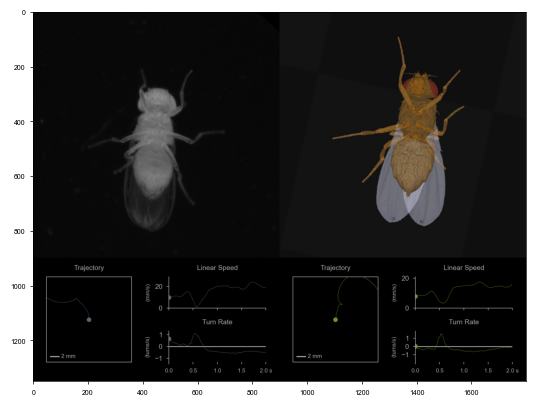

In [239]:
plt.imshow(out_frame)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import imageio as iio
from tqdm import trange


class TrajectoryPlotter:
    def __init__(
        self,
        traj,
        heading_ts,
        linspeed,
        turnrate,
        dt,
        datacolor="tab:blue",
        fgcolor="#aaaaaa",
        extent=20,
        ylim_margin=0.2,
        dpi=300,
    ):
        self.traj = np.array(traj)
        self.heading_ts = heading_ts
        self.linspeed = np.array(linspeed)
        self.turnrate = np.array(turnrate) / (2 * np.pi)  # convert to turns/s
        self.t_grid = np.arange(self.traj.shape[0]) * dt

        self.traj_halfextent = extent / 2
        self.ylim_margin = ylim_margin
        self.dpi = dpi
        self.datacolor = datacolor
        self.fgcolor = fgcolor

        figsize_px = (OUTPUT_VIDEO_BLOCKDIM, OUTPUT_VIDEO_BLOCKDIM // 2)
        self.fig = plt.figure(
            figsize=[x / dpi for x in figsize_px], tight_layout=True, dpi=self.dpi
        )
        gs = gridspec.GridSpec(2, 2, figure=self.fig)
        self.ax_traj = self.fig.add_subplot(gs[:, 0])
        self.ax_linspeed = self.fig.add_subplot(gs[0, 1])
        self.ax_turnrate = self.fig.add_subplot(gs[1, 1])

        self._setup()

    def _style_ax(self, ax):
        ax.set_facecolor((0, 0, 0, 0.5))
        for spine in ax.spines.values():
            spine.set_color(self.fgcolor)
        ax.tick_params(colors=self.fgcolor, labelsize=6)

    def _setup(self):
        self.fig.patch.set_facecolor((0, 0, 0, 1))
        self.fig.subplots_adjust(0, 0, 1, 1, wspace=0.3, hspace=0.3)

        # Trajectory axes
        self.ax_traj.set_aspect("equal")
        self._style_ax(self.ax_traj)
        self.ax_traj.set_xticks([])
        self.ax_traj.set_yticks([])
        (self.line_past,) = self.ax_traj.plot([], [], color=self.color, linewidth=1.5)
        (self.line_future,) = self.ax_traj.plot(
            [], [], color=self.color, linewidth=0.5, alpha=0.5
        )
        (self.dot,) = self.ax_traj.plot(
            [], [], marker="o", color=self.color, markersize=5, linestyle="none"
        )
        self.ax_traj.plot(
            [-0.9 * self.traj_halfextent, -0.9 * self.traj_halfextent + 2],
            [-0.87 * self.traj_halfextent, -0.87 * self.traj_halfextent],
            color=self.fgcolor,
            linewidth=1,
        )
        self.ax_traj.text(
            -0.9 * self.traj_halfextent + 2.5,
            -0.87 * self.traj_halfextent,
            "2 mm",
            color=self.fgcolor,
            fontsize=5,
            va="center",
            ha="left",
        )
        self.ax_traj.set_title("Trajectory", color=self.fgcolor, fontsize=6)

        # Linspeed axes
        self._style_ax(self.ax_linspeed)
        self.ax_linspeed.set_xlim(0, self.t_grid[-1])
        self.ax_linspeed.set_xticklabels([])
        self.ax_linspeed.set_ylim(0, self.linspeed.max() * (1 + self.ylim_margin))
        self.ax_linspeed.set_ylabel("(mm/s)", color=self.fgcolor, fontsize=5)
        (self.ls_past,) = self.ax_linspeed.plot([], [], color=self.color, linewidth=1.5)
        (self.ls_future,) = self.ax_linspeed.plot(
            [], [], color=self.color, linewidth=0.5, alpha=0.5
        )
        (self.ls_dot,) = self.ax_linspeed.plot(
            [], [], marker="o", color=self.color, markersize=3, linestyle="none"
        )
        self.ax_linspeed.set_title("Linear Speed", color=self.fgcolor, fontsize=6)
        sns.despine(ax=self.ax_linspeed)

        # Turnrate axes
        self._style_ax(self.ax_turnrate)
        self.ax_turnrate.set_xlim(0, self.t_grid[-1])
        y_absmax_with_margin = np.max(np.abs(self.turnrate)) * (1 + self.ylim_margin)
        self.ax_turnrate.set_ylim(-y_absmax_with_margin, y_absmax_with_margin)
        self.ax_turnrate.set_ylabel("(turns/s)", color=self.fgcolor, fontsize=5)
        (self.tr_past,) = self.ax_turnrate.plot([], [], color=self.color, linewidth=1.5)
        xticklabels = self.ax_turnrate.get_xticklabels()
        xticklabels[-1].set_text(xticklabels[-1].get_text() + " s")
        self.ax_turnrate.set_xticks(
            self.ax_turnrate.get_xticks(), labels=xticklabels, fontsize=5
        )
        (self.tr_future,) = self.ax_turnrate.plot(
            [], [], color=self.color, linewidth=0.5, alpha=0.5
        )
        (self.tr_dot,) = self.ax_turnrate.plot(
            [], [], marker="o", color=self.color, markersize=3, linestyle="none"
        )
        self.ax_turnrate.set_title("Turn Rate", color=self.fgcolor, fontsize=6)
        sns.despine(ax=self.ax_turnrate, bottom=True)
        self.ax_turnrate.axhline(0, color=self.fgcolor, linewidth=0.75, zorder=-100)

    def _rotate(self, t):
        angle = np.pi / 2 - self.heading_ts[t]
        c, s = np.cos(angle), np.sin(angle)
        R = np.array([[c, -s], [s, c]])
        return (self.traj - self.traj[t]) @ R.T

    def plot_snapshot(self, t):
        # Trajectory
        traj_r = self._rotate(t)
        cx, cy = traj_r[t]
        self.line_past.set_data(traj_r[:t, 0], traj_r[:t, 1])
        self.line_future.set_data(traj_r[t:, 0], traj_r[t:, 1])
        self.dot.set_data([traj_r[t, 0]], [traj_r[t, 1]])
        self.ax_traj.set_xlim(cx - self.traj_halfextent, cx + self.traj_halfextent)
        self.ax_traj.set_ylim(cy - self.traj_halfextent, cy + self.traj_halfextent)

        # Linear speed
        self.ls_past.set_data(self.t_grid[:t], self.linspeed[:t])
        self.ls_future.set_data(self.t_grid[t:], self.linspeed[t:])
        self.ls_dot.set_data([self.t_grid[t]], [self.linspeed[t]])

        # Turn rate
        self.tr_past.set_data(self.t_grid[:t], self.turnrate[:t])
        self.tr_future.set_data(self.t_grid[t:], self.turnrate[t:])
        self.tr_dot.set_data([self.t_grid[t]], [self.turnrate[t]])

        self.fig.canvas.draw()
        return np.asarray(self.fig.canvas.buffer_rgba())

    def make_video(self, output_path, fps):
        output_path.parent.mkdir(exist_ok=True, parents=True)
        with iio.imopen(str(output_path), "w", plugin="pyav") as writer:
            writer.init_video_stream("h264", fps=fps)
            for t in trange(len(self.traj)):
                frame = self.plot_snapshot(t)
                writer.write_frame(frame[:, :, :3])

  0%|          | 0/67 [00:00<?, ?it/s]

100%|██████████| 67/67 [00:03<00:00, 19.22it/s]


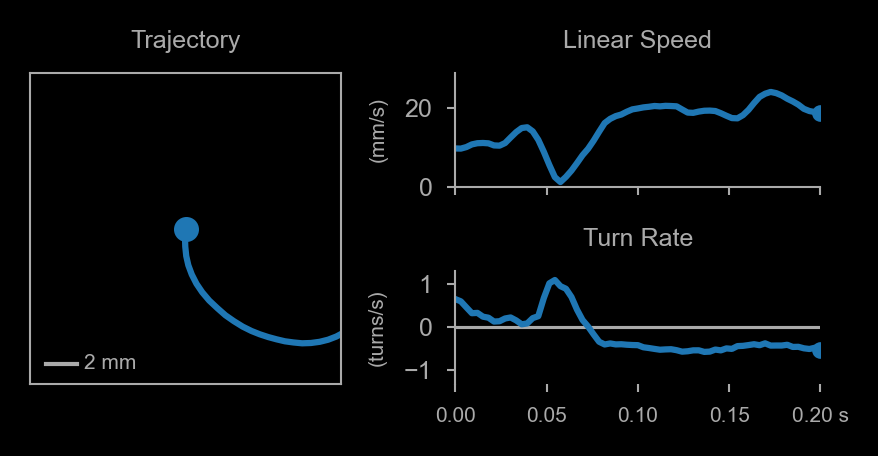

In [ ]:
frame_pairs = frame_pairs_full[::10]
# frame_pairs = frame_pairs_full[:]
rectraj_to_plot = [traj_info["basetraj_rec_filtered"][idx] for _, idx, _ in frame_pairs]
recheading_to_plot = [traj_info["baseheading_rec"][idx] for _, idx, _ in frame_pairs]
reclinspeed_to_plot = [traj_info["baselinspeed_rec"][idx] for _, idx, _ in frame_pairs]
recturnrate_to_plot = [traj_info["baseturnrate_rec"][idx] for _, idx, _ in frame_pairs]
dt = 1 / (VIDEO_OUTPUT_FPS / VIDEO_PLAYBACK_SPEED)
traj_plotter = TrajectoryPlotter(
    rectraj_to_plot, recheading_to_plot, reclinspeed_to_plot, recturnrate_to_plot, dt
)
traj_plotter.make_video(VISUALIZED_SIM_DIR / "trajectory.mp4", fps=VIDEO_OUTPUT_FPS)

  0%|          | 0/67 [00:00<?, ?it/s]

100%|██████████| 67/67 [00:03<00:00, 18.98it/s]


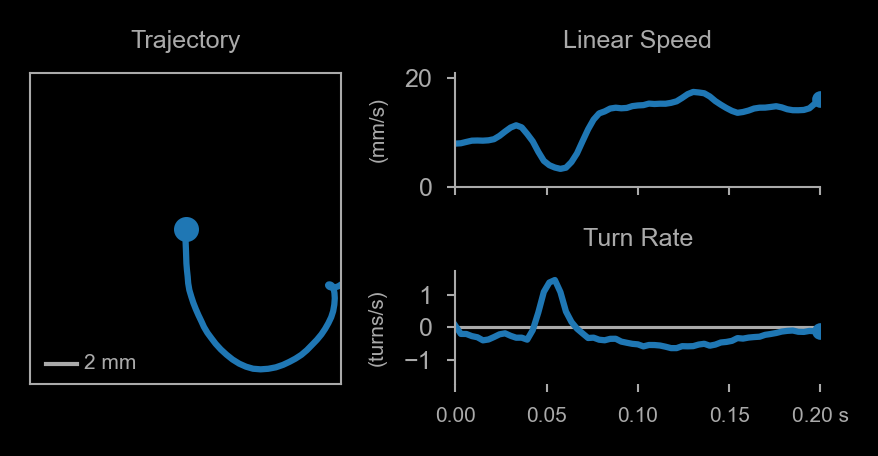

In [223]:
frame_pairs = frame_pairs_full[::10]
# frame_pairs = frame_pairs_full[:]
rectraj_to_plot = [traj_info["basetraj_sim_filtered"][idx] for _, idx, _ in frame_pairs]
recheading_to_plot = [traj_info["baseheading_sim"][idx] for _, idx, _ in frame_pairs]
reclinspeed_to_plot = [traj_info["baselinspeed_sim"][idx] for _, idx, _ in frame_pairs]
recturnrate_to_plot = [traj_info["baseturnrate_sim"][idx] for _, idx, _ in frame_pairs]
dt = 1 / (VIDEO_OUTPUT_FPS / VIDEO_PLAYBACK_SPEED)
traj_plotter = TrajectoryPlotter(
    rectraj_to_plot, recheading_to_plot, reclinspeed_to_plot, recturnrate_to_plot, dt
)
traj_plotter.make_video(VISUALIZED_SIM_DIR / "trajectory.mp4", fps=VIDEO_OUTPUT_FPS)

In [63]:
traj_info["baseheading_rec"]

array([-1.02555188, -1.02018884, -1.01476332, ..., -3.30080542,
       -3.32133249, -3.3417799 ], shape=(1146,))